# PyCaret aplicado a problemas de classificação binária 

## Tutorial de utilização

* Demonstrar como a biblioteca PyCaret pode ser usada em problemas de classificação binária.

## Contextualização

* Identificar a chance de um paciente ter uma doença cardíaca com base num conjunto de variáveis explicativas (*features*).
* O modelo a ser desenvolvido entrega uma probabilidade (um número entre 0 e 1) que quantifica a chance do paciente ter uma doença cardíaca. Quanto maior o valor, maior a chance de ter esta doença.

## Métrica de avaliação

* Estatística KS.
    * Mais detalhes: [Teste de Kolmogorov-Smirnov](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test)

### OBS

* Antes da aplicação do Pycaret, será mostrado uma análise exploratória dos dados (EDA) visando encontrar quais as variáveis que mais afetam a chance do paciente possuir uma doença cardíaca. 


In [1]:
#Imports
import pandas as pd     #Manipulação dos dados
import numpy as np      #Operações multidimensionais e matemáticas
from scipy import stats #Cálculo do KS
from scipy.stats import ks_2samp #Cálculo do KS
import matplotlib.pyplot as plt #Visualização dos dados
import seaborn as sns #Visualização de dados
##Machine learning
from pycaret.classification import * 
from scipy.stats import ks_2samp##Eliminar os warnings
import warnings
warnings.filterwarnings("ignore")
##Ver todas as colunas do data frame
pd.set_option('display.max_columns', None)
##Extrair os valores do feature importance
import sklearn as sk

In [2]:
##########################################
##Métrica de Avaliação:
#KS (Kolmogorov-Smirnov)
##########################################
def calcular_ks_2samp(df, alvo, escore):
    bons_escore = df.loc[df[alvo] == 0, escore].rename('bons')
    maus_escore = df.loc[df[alvo] == 1, escore].rename('maus')
    return stats.ks_2samp(bons_escore, maus_escore).statistic

* **OBS**: Se você deseja reproduzir esse código, é recomendado instalar as versões do **Python e do PyCaret indicadas abaixo**.


In [3]:
#Versão do Python: 3.9.13
import sys
print(sys.version)

3.9.13 (main, Oct 13 2022, 21:23:06) [MSC v.1916 64 bit (AMD64)]


In [4]:
#Versão do PyCaret: 3.3.1
!pip show pycaret 

Name: pycaret
Version: 3.3.1
Summary: PyCaret - An open source, low-code machine learning library in Python.
Home-page: https://github.com/pycaret/pycaret
Author: Moez Ali
Author-email: moez.ali@queensu.ca
License: MIT
Location: c:\users\zaian\anaconda3\envs\pycaret_env\lib\site-packages
Requires: category-encoders, cloudpickle, deprecation, imbalanced-learn, importlib-metadata, ipython, ipywidgets, jinja2, joblib, kaleido, lightgbm, markupsafe, matplotlib, nbformat, numba, numpy, pandas, plotly, plotly-resampler, pmdarima, psutil, pyod, requests, schemdraw, scikit-learn, scikit-plot, scipy, sktime, statsmodels, tbats, tqdm, xxhash, yellowbrick
Required-by: 


# 1 - Visão geral dos dados

In [5]:
#Importar os dados
df = pd.read_csv("dados_pycaret.csv", sep = ',')
#Visualizar as 4 primeiras linhas da base de dados
df.head(4)

,Age,Sex,Chest_pain,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment,Number_of_major_vessels,Thal,ALVO
0,63,MALE,LEVEL_1,145,233,HIGH,LEVEL_2,150,NO_PAIN,2.3,LEVEL_3,0.0,LEVEL_6,0
1,67,MALE,LEVEL_4,160,286,LOW,LEVEL_2,108,PAIN,1.5,LEVEL_2,3.0,LEVEL_3,1
2,67,MALE,LEVEL_4,120,229,LOW,LEVEL_2,129,PAIN,2.6,LEVEL_2,2.0,LEVEL_7,1
3,37,MALE,LEVEL_3,130,250,LOW,LEVEL_0,187,NO_PAIN,3.5,LEVEL_3,0.0,LEVEL_3,0


## 1.1 - Descritivo das variáveis

1. **ALVO**: Variável binária que diz se o paciente sofre ou não de alguma doença cardíaca:
    * 1 - Paciente apresenta alguma doença cardíaca; 
    * 0 - Paciente não apresenta doença cardíaca.
2. **Age**: Variável quantitativa que informa a idade do paciente, mensurada em anos;
3. **Sex**: Variável binária que informa o sexo do paciente:
4. **Chest_pain**: Variável categórica relacionada ao tipo de dor no peito sentida pelo paciente, segmentada em quatro categorias;
5. **Resting Blood Pressure**: Variável quantitativa que mede a pressão arterial do paciente em estado de repouso, mensurada em milímetros de mercúrio (mm Hg);
6. **Serum_cholestrol**: Variável quantitativa que mede o colesterol do paciente, mensurada em miligramas por decilitro (mg/dL);
7. **Fasting_blood_sugar**: Variável binária que compara o valor de açúcar no sangue do paciente em jejum: 
    * HIGH - Se a glicose for maior que  120mg/dl;
    * LOW - Se a glicose for menor que  120mg/dl.
8. **Resting ECG**: Variável categórica relacionada ao resultado do eletrocardiograma do paciente em estado de repouso. Ela foi segmentada em três categorias; 
9. **Max_heart_rate_achieved**: Variável quantitativa que mede a frequência máxima cardíaca atingida pelo paciente, mensurada em bpm - batimentos por minuto;
10. **Exercise_induced_angina**: Variável binária que informa se o paciente sente uma dor cardiáca relacionada a execução de um esforço físico ou estado de extresse:
    * PAIN - presença de dor;
    * NO_PAIN - ausência de dor.
11. **ST_depression**: Variável quantitativa que mede a depressão do segmento ST induzida por exercício em relação repouso;
12. **Peak_exercise_ST_segment**: Variável categórica que descrimina o tipo de segmento ST. Ela apresenta em três categorias;
13. **Number_of_major_vessels**: Variável quantitativa que mede o número de vasos principais (0–3) coloridos por fluoroscopia;
14. **Thal**: Variável categórica relacionada a um grupo de doenças no sangue relacionada a anomalias na produção de hemoglobina, segmentada em três categorias.

## 1.2 - Informações preliminares da base de dados

In [6]:
#Total de observações 
df.shape[0] #303

303

In [7]:
#Características gerais do data frame
df.info() 
##Tipo das variáveis:
#1. int64 implica que a variável é quantitativa inteira; 
#2. float64 implica que a variável é quantitativa contínua;
#3. object implica que a variável é categórica (texto).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       303 non-null    int64  
 1   Sex                       303 non-null    object 
 2   Chest_pain                303 non-null    object 
 3   Resting_blood_pressure    303 non-null    int64  
 4   Serum_cholestrol          303 non-null    int64  
 5   Fasting_blood_sugar       303 non-null    object 
 6   Resting_ECG               303 non-null    object 
 7   Max_heart_rate_achieved   303 non-null    int64  
 8   Exercise_induced_angina   303 non-null    object 
 9   ST_depression             303 non-null    float64
 10  Peak_exercise_ST_segment  303 non-null    object 
 11  Number_of_major_vessels   299 non-null    float64
 12  Thal                      301 non-null    object 
 13  ALVO                      303 non-null    int64  
dtypes: float64

## 1.3 - EDA

### A - Taxa de ocorrência do ALVO

In [8]:
#Taxa de ocorrência do ALVO
round(100 * df['ALVO'].value_counts(True),2) #Aproximadamente, 46% dos pacientes apresentam alguma doença cardíaca

0    54.13
1    45.87
Name: ALVO, dtype: float64

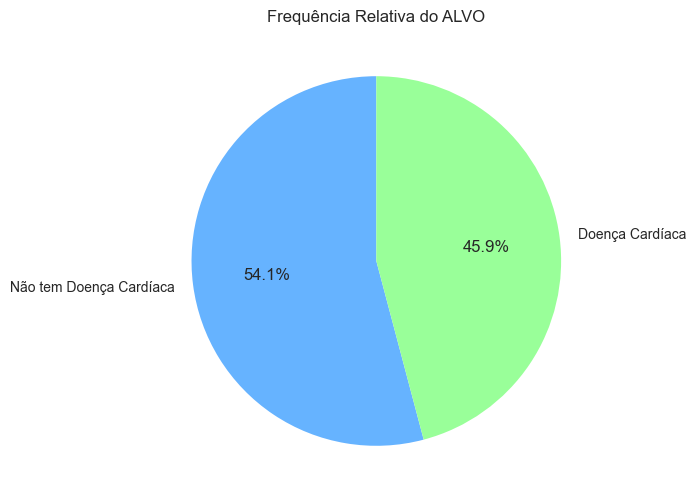

In [9]:
#Abordagem visual

## Calculando a frequência relativa
freq_relativa_alvo = df['ALVO'].value_counts(normalize=True)

## Mapeando os rótulos
labels = {1: 'Doença Cardíaca', 0: 'Não tem Doença Cardíaca'}
new_labels = [labels.get(i, i) for i in freq_relativa_alvo.index]

## Criando o gráfico de pizza
plt.figure(figsize=(6, 6))
plt.pie(freq_relativa_alvo, labels=new_labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])

## Título
plt.title('Frequência Relativa do ALVO')

## Exibir o gráfico
plt.show()


### B - Análise univariada

**Variáveis categóricas**

* **Objetivo**: Encontrar a frequência relativa de cada classe para cada variável.

In [10]:
#Frequência relativa 
##Filtrar todas as colunas que são do tipo object e calcular a frequência relativa
for coluna in df.select_dtypes(include = "object"):
    print (f"{coluna}:\n{df[coluna].value_counts(True)}")
#A partir destes resultados, pode-se calcular a cardinalidade de cada classe    

Sex:
MALE      0.679868
FEMALE    0.320132
Name: Sex, dtype: float64
Chest_pain:
LEVEL_4    0.475248
LEVEL_3    0.283828
LEVEL_2    0.165017
LEVEL_1    0.075908
Name: Chest_pain, dtype: float64
Fasting_blood_sugar:
LOW     0.851485
HIGH    0.148515
Name: Fasting_blood_sugar, dtype: float64
Resting_ECG:
LEVEL_0    0.498350
LEVEL_2    0.488449
LEVEL_1    0.013201
Name: Resting_ECG, dtype: float64
Exercise_induced_angina:
NO_PAIN    0.673267
PAIN       0.326733
Name: Exercise_induced_angina, dtype: float64
Peak_exercise_ST_segment:
LEVEL_1    0.468647
LEVEL_2    0.462046
LEVEL_3    0.069307
Name: Peak_exercise_ST_segment, dtype: float64
Thal:
LEVEL_3    0.551495
LEVEL_7    0.388704
LEVEL_6    0.059801
Name: Thal, dtype: float64


**Variáveis quantiativas**

* **Objetivo**: Calcular as principais medidas de posição e de variação.

In [11]:
#Obter as colunas numéricas
##Extraíndo os tipos FLOAT e INT: numéricos
tipos_desejados = ['int64', 'float64']
###Nota: Vou excluir o ALVO da análise
colunas_desejadas = [coluna for coluna in df.select_dtypes(include=tipos_desejados) if coluna != 'ALVO']
#Visualizar
colunas_desejadas

['Age',
 'Resting_blood_pressure',
 'Serum_cholestrol',
 'Max_heart_rate_achieved',
 'ST_depression',
 'Number_of_major_vessels']

In [12]:
#Sumário estatístico das variáveis numéricas
for coluna in colunas_desejadas:
    print(f"--- {coluna} ---")
    print(f"Média: {df[coluna].mean()}")
    print(f"Mediana: {df[coluna].median()}")
    print(f"Máximo: {df[coluna].max()}")
    print(f"Mínimo: {df[coluna].min()}")
    print(f"Desvio Padrão: {df[coluna].std()}")
    print(f"Coeficiente de variação: {df[coluna].std()/df[coluna].mean() * 100}")
    print()

--- Age ---
Média: 54.43894389438944
Mediana: 56.0
Máximo: 77
Mínimo: 29
Desvio Padrão: 9.038662442446746
Coeficiente de variação: 16.603302334412636

--- Resting_blood_pressure ---
Média: 131.68976897689768
Mediana: 130.0
Máximo: 200
Mínimo: 94
Desvio Padrão: 17.59974772958769
Coeficiente de variação: 13.364552057704051

--- Serum_cholestrol ---
Média: 246.69306930693068
Mediana: 241.0
Máximo: 564
Mínimo: 126
Desvio Padrão: 51.77691754263704
Coeficiente de variação: 20.9883956967665

--- Max_heart_rate_achieved ---
Média: 149.6072607260726
Mediana: 153.0
Máximo: 202
Mínimo: 71
Desvio Padrão: 22.875003276980376
Coeficiente de variação: 15.290035500926638

--- ST_depression ---
Média: 1.0396039603960396
Mediana: 0.8
Máximo: 6.2
Mínimo: 0.0
Desvio Padrão: 1.1610750220686348
Coeficiente de variação: 111.68435926564963

--- Number_of_major_vessels ---
Média: 0.6722408026755853
Mediana: 0.0
Máximo: 3.0
Mínimo: 0.0
Desvio Padrão: 0.9374383177242163
Coeficiente de variação: 139.44977960176152

### C - Análise bivariada

* Cruzar o ALVO com as variáveis explicativas.

#### ALVO com variáveis categóricas

In [13]:
#Lista de colunas categóricas
colunas_categoricas = df.select_dtypes(include='object').columns
#Colunas
colunas_categoricas

Index(['Sex', 'Chest_pain', 'Fasting_blood_sugar', 'Resting_ECG',
       'Exercise_induced_angina', 'Peak_exercise_ST_segment', 'Thal'],
      dtype='object')

* **Objetivo**: Analisar se a taxa de frequência do ALVO muda conforme avaliamos para cada classe.

In [14]:
#Iterando sobre as colunas categóricas
for coluna in colunas_categoricas:
    print(f"Análise bivariada {coluna}:")
    summary = df.groupby([coluna])['ALVO'].agg(['mean'])
    summary.columns = ['Média']
    print(summary)
    print('\n')

Análise bivariada Sex:
           Média
Sex             
FEMALE  0.257732
MALE    0.553398


Análise bivariada Chest_pain:
               Média
Chest_pain          
LEVEL_1     0.304348
LEVEL_2     0.180000
LEVEL_3     0.209302
LEVEL_4     0.729167


Análise bivariada Fasting_blood_sugar:
                        Média
Fasting_blood_sugar          
HIGH                 0.488889
LOW                  0.453488


Análise bivariada Resting_ECG:
                Média
Resting_ECG          
LEVEL_0      0.370861
LEVEL_1      0.750000
LEVEL_2      0.540541


Análise bivariada Exercise_induced_angina:
                            Média
Exercise_induced_angina          
NO_PAIN                  0.308824
PAIN                     0.767677


Análise bivariada Peak_exercise_ST_segment:
                             Média
Peak_exercise_ST_segment          
LEVEL_1                   0.253521
LEVEL_2                   0.650000
LEVEL_3                   0.571429


Análise bivariada Thal:
            Média
T

#### ALVO com variáveis numéricas

**Estatística descritiva**

In [15]:
#Lista das colunas numéricas sem ALVO
colunas_numericas = df.drop(columns=['ALVO']).select_dtypes(include=['int64', 'float64']).columns
colunas_numericas

Index(['Age', 'Resting_blood_pressure', 'Serum_cholestrol',
       'Max_heart_rate_achieved', 'ST_depression', 'Number_of_major_vessels'],
      dtype='object')

* **Objetivo**: Na análise bivariada entre o ALVO e as variáveis quantitativas, avaliamos se a distribuição destas difere em função das categorias do ALVO.

In [16]:
#Iterando sobre as colunas categóricas
for coluna in colunas_numericas:
    print(f"Análise bivariada {coluna}:")
    summary = df.groupby(['ALVO'])[coluna].agg(['mean', 'median', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    summary.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Percentil 25', 'Percentil 75']
    print(summary)
    print('\n')

Análise bivariada Age:
          Média  Mediana  Desvio Padrão  Percentil 25  Percentil 75
ALVO                                                               
0     52.585366     52.0       9.511957         44.75          59.0
1     56.625899     58.0       7.938416         52.00          62.0


Análise bivariada Resting_blood_pressure:
           Média  Mediana  Desvio Padrão  Percentil 25  Percentil 75
ALVO                                                                
0     129.250000    130.0      16.204739         120.0         140.0
1     134.568345    130.0      18.769019         120.0         145.0


Análise bivariada Serum_cholestrol:
           Média  Mediana  Desvio Padrão  Percentil 25  Percentil 75
ALVO                                                                
0     242.640244    234.5      53.456580        208.75        267.25
1     251.474820    249.0      49.486835        217.50        283.50


Análise bivariada Max_heart_rate_achieved:
           Média  Mediana 

**Cáculo do KS**

In [17]:
#Lista das variáveis que serão calculadas o KS
colunas_var_quant = colunas_numericas.tolist()
#Visualização
colunas_var_quant 

['Age',
 'Resting_blood_pressure',
 'Serum_cholestrol',
 'Max_heart_rate_achieved',
 'ST_depression',
 'Number_of_major_vessels']

In [18]:
#Data frame das colunas numéricas
tabela_numerica = df[['ALVO', 'Age', 'Resting_blood_pressure','Serum_cholestrol','Max_heart_rate_achieved','ST_depression','Number_of_major_vessels']]
#Visualização
tabela_numerica.head(3)

,ALVO,Age,Resting_blood_pressure,Serum_cholestrol,Max_heart_rate_achieved,ST_depression,Number_of_major_vessels
0,0,63,145,233,150,2.3,0.0
1,1,67,160,286,108,1.5,3.0
2,1,67,120,229,129,2.6,2.0


In [19]:
#Criação de um dicionário que vai receber a estatística KS para cada variável
dicionario = {}
#Aplicação de um laço para o cálculo do KS2 da lista de variáveis em colunas_var_quant
for coluna in colunas_var_quant:
   resultado = calcular_ks_2samp(tabela_numerica,'ALVO', coluna)
   dicionario[coluna] = resultado
#KS das variáveis
dicionario # A estatística do KS vai de 0 a 1. Maior KS, maior é o poder discriminatório da variável quantitativa em separar os pacientes que tem doenças cardíacas com os que não.

{'Age': 0.2871117739954378,
 'Resting_blood_pressure': 0.12094227057378487,
 'Serum_cholestrol': 0.15651868748903316,
 'Max_heart_rate_achieved': 0.4085804527110019,
 'ST_depression': 0.3962537287243376,
 'Number_of_major_vessels': 0.4617476750307071}

#### Tabela de correlação

* Aplicado as variáveis numéricas.

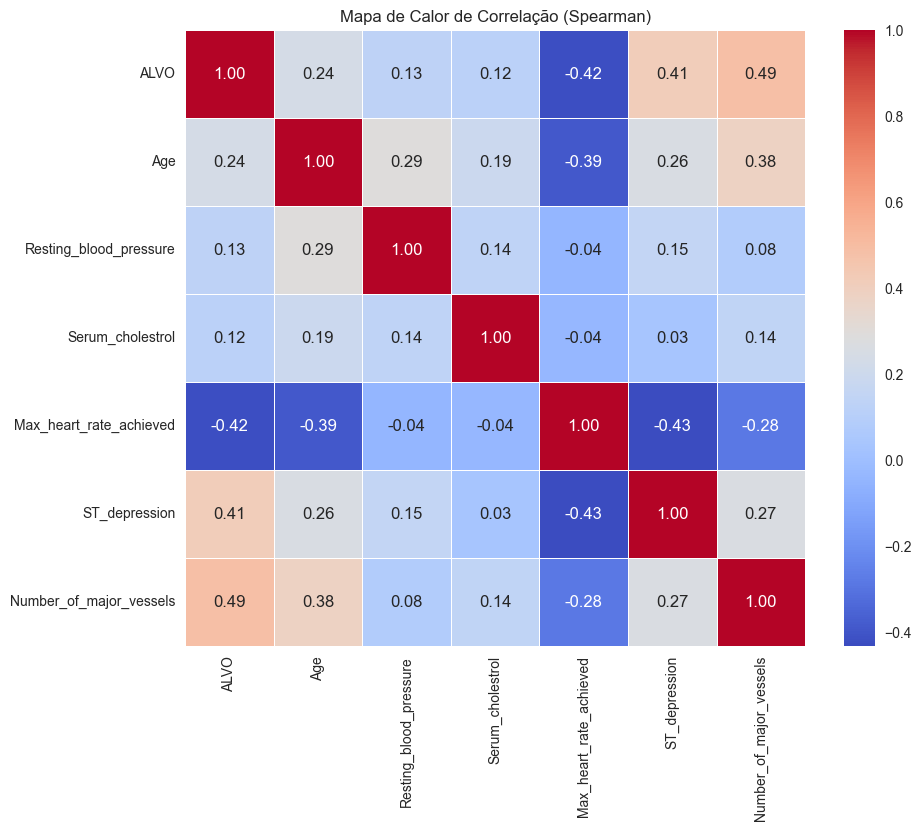

In [20]:
# Supondo que tabela_numerica já seja um DataFrame com variáveis quantitativas
# Calcula a matriz de correlação de Spearman
correlacao_spearman = tabela_numerica.corr(method='spearman')

# Configura o tamanho do gráfico
plt.figure(figsize=(10, 8))

# Cria o heatmap
sns.heatmap(correlacao_spearman, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Adiciona título
plt.title('Mapa de Calor de Correlação (Spearman)')

# Exibe o gráfico
plt.show()

# 2 - Pycaret

## 2.1 - Setup

In [21]:
# Configuração do PyCaret
exp = setup(
    data=df,
    target="ALVO",  # Substitua pelo nome da coluna target
    normalize=True,  # Normalização dos dados
    train_size=0.65,  # Tamanho do conjunto de treino
    normalize_method="minmax",  # Método de normalização
    numeric_imputation='median',  # Imputação de valores numéricos faltantes
    remove_outliers = True,
    categorical_imputation='mode',  # Imputação de valores categóricos faltantes
    session_id=1935,  # Semente para reproducibilidade
    experiment_name="EXP_02_03_2025"  # Nome do experimento
)

,Description,Value
0,Session id,1935
1,Target,ALVO
2,Target type,Binary
3,Original data shape,"(303, 14)"
4,Transformed data shape,"(293, 23)"
5,Transformed train set shape,"(186, 23)"
6,Transformed test set shape,"(107, 23)"
7,Numeric features,6
8,Categorical features,7
9,Rows with missing values,2.0%


In [22]:
#Base de treino
df_treino = get_config('train')
#Visualização
df_treino.head(3)

,Age,Sex,Chest_pain,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment,Number_of_major_vessels,Thal,ALVO
104,49,MALE,LEVEL_3,120,188,LOW,LEVEL_0,139,NO_PAIN,2.0,LEVEL_2,3.0,LEVEL_7,1
277,39,FEMALE,LEVEL_3,138,220,LOW,LEVEL_0,152,NO_PAIN,0.0,LEVEL_2,0.0,LEVEL_3,0
248,52,MALE,LEVEL_4,125,212,LOW,LEVEL_0,168,NO_PAIN,1.0,LEVEL_1,2.0,LEVEL_7,1


In [23]:
#As variáveis da base de treino transformadas após o pré-processamento
X = get_config('X_train_transformed')
X.head(3)

,Age,Sex,Chest_pain_LEVEL_3,Chest_pain_LEVEL_4,Chest_pain_LEVEL_1,Chest_pain_LEVEL_2,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG_LEVEL_0,Resting_ECG_LEVEL_2,Resting_ECG_LEVEL_1,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment_LEVEL_2,Peak_exercise_ST_segment_LEVEL_1,Peak_exercise_ST_segment_LEVEL_3,Number_of_major_vessels,Thal_LEVEL_7,Thal_LEVEL_3,Thal_LEVEL_6
104,0.405405,1.0,1.0,0.0,0.0,0.0,0.302326,0.141553,1.0,1.0,0.0,0.0,0.490385,0.0,0.526316,1.0,0.0,0.0,1.000000,1.0,0.0,0.0
277,0.135135,0.0,1.0,0.0,0.0,0.0,0.511628,0.214612,1.0,1.0,0.0,0.0,0.615385,0.0,0.000000,1.0,0.0,0.0,0.000000,0.0,1.0,0.0
248,0.486486,1.0,0.0,1.0,0.0,0.0,0.360465,0.196347,1.0,1.0,0.0,0.0,0.769231,0.0,0.263158,0.0,1.0,0.0,0.666667,1.0,0.0,0.0


In [24]:
#Base de teste 
df_teste = get_config('test')
#Visualização
df_teste.head(3)

,Age,Sex,Chest_pain,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment,Number_of_major_vessels,Thal,ALVO
159,68,MALE,LEVEL_3,118,277,LOW,LEVEL_0,151,NO_PAIN,1.0,LEVEL_1,1.0,LEVEL_7,0
173,62,FEMALE,LEVEL_4,140,394,LOW,LEVEL_2,157,NO_PAIN,1.2,LEVEL_2,0.0,LEVEL_3,0
44,61,FEMALE,LEVEL_4,130,330,LOW,LEVEL_2,169,NO_PAIN,0.0,LEVEL_1,0.0,LEVEL_3,1


## 2.2 - Compare models

In [25]:
compare_models() 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.8368,0.0000,0.7667,0.8720,0.8105,0.6678,0.6786,0.8580
gbc,Gradient Boosting Classifier,0.8321,0.9025,0.8111,0.8227,0.8119,0.6598,0.6671,0.0960
rf,Random Forest Classifier,0.8318,0.0000,0.7778,0.8518,0.8100,0.6592,0.6651,0.1010
lr,Logistic Regression,0.8313,0.9128,0.7778,0.8536,0.8065,0.6575,0.6672,0.5300
et,Extra Trees Classifier,0.8268,0.0000,0.7444,0.8650,0.7929,0.6463,0.6591,0.1000
lda,Linear Discriminant Analysis,0.8261,0.8983,0.7667,0.8621,0.8022,0.6471,0.6608,0.0690
ridge,Ridge Classifier,0.8208,0.9037,0.7556,0.8625,0.7931,0.6359,0.6516,0.0680
lightgbm,Light Gradient Boosting Machine,0.8166,0.0000,0.7778,0.8248,0.7918,0.6278,0.6416,0.0930
knn,K Neighbors Classifier,0.8111,0.0000,0.7889,0.8040,0.7922,0.6187,0.6245,0.0700
xgboost,Extreme Gradient Boosting,0.8111,0.0000,0.7667,0.8231,0.7880,0.6175,0.6264,0.0800


## 2.3 - Create model

### Regressão Logística

In [26]:
model = create_model('lr') 
model

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.9091,0.7778,0.7778,0.7778,0.5960,0.5960
1,0.7000,0.6768,0.4444,0.8000,0.5714,0.3684,0.4062
2,0.9000,0.9596,0.8889,0.8889,0.8889,0.7980,0.7980
3,0.8500,0.9091,0.7778,0.8750,0.8235,0.6939,0.6975
4,0.9500,0.9495,0.8889,1.0000,0.9412,0.8980,0.9027
5,0.8500,0.9798,0.7778,0.8750,0.8235,0.6939,0.6975
6,0.8421,0.9333,0.7778,0.8750,0.8235,0.6816,0.6854
7,0.7895,0.9222,0.7778,0.7778,0.7778,0.5778,0.5778
8,0.7368,0.9333,0.8889,0.6667,0.7619,0.4809,0.5060


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1935, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

### Comparar os KS das base de treino e teste

In [27]:
#Avaliar o modelo na base de teste
df_treino = predict_model(model, data = df_treino, raw_score=True)
#Visualização
df_treino.head(3) #prediction_score_1 é a chance de ter a doença cardíaca

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8622,0.9396,0.8000,0.8889,0.8421,0.7205,0.7237


,Age,Sex,Chest_pain,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment,Number_of_major_vessels,Thal,ALVO,prediction_label,prediction_score_0,prediction_score_1
104,49,MALE,LEVEL_3,120,188,LOW,LEVEL_0,139,NO_PAIN,2.0,LEVEL_2,3.0,LEVEL_7,1,1,0.1619,0.8381
277,39,FEMALE,LEVEL_3,138,220,LOW,LEVEL_0,152,NO_PAIN,0.0,LEVEL_2,0.0,LEVEL_3,0,0,0.9646,0.0354
248,52,MALE,LEVEL_4,125,212,LOW,LEVEL_0,168,NO_PAIN,1.0,LEVEL_1,2.0,LEVEL_7,1,1,0.1692,0.8308


In [28]:
#KS
calcular_ks_2samp(df_treino, 'ALVO', 'prediction_score_1') #74%

0.7362683438155136

In [29]:
#Avaliar o modelo na base de teste
df_teste = predict_model(model, data = df_teste, raw_score=True)
#Visualização
df_teste.head(3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8411,0.9043,0.8163,0.8333,0.8247,0.6795,0.6796


,Age,Sex,Chest_pain,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment,Number_of_major_vessels,Thal,ALVO,prediction_label,prediction_score_0,prediction_score_1
159,68,MALE,LEVEL_3,118,277,LOW,LEVEL_0,151,NO_PAIN,1.0,LEVEL_1,1.0,LEVEL_7,0,0,0.7276,0.2724
173,62,FEMALE,LEVEL_4,140,394,LOW,LEVEL_2,157,NO_PAIN,1.2,LEVEL_2,0.0,LEVEL_3,0,1,0.4795,0.5205
44,61,FEMALE,LEVEL_4,130,330,LOW,LEVEL_2,169,NO_PAIN,0.0,LEVEL_1,0.0,LEVEL_3,1,0,0.8114,0.1886


In [30]:
calcular_ks_2samp(df_teste, 'ALVO', 'prediction_score_1') #71%

0.7083040112596762

Estatística KS: 0.7083040112596762
Valor-p: 2.3126606932793453e-13


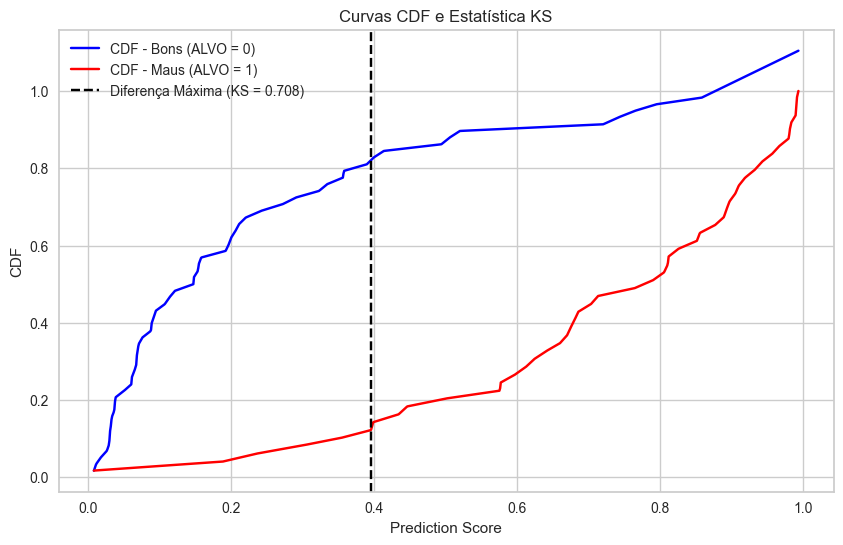

In [31]:
# Separar as previsões para as classes 0 e 1
bons = df_teste[df_teste['ALVO'] == 0]['prediction_score_1']
maus = df_teste[df_teste['ALVO'] == 1]['prediction_score_1']

# Calcular a estatística KS
ks_statistic, ks_pvalue = ks_2samp(bons, maus)
print(f"Estatística KS: {ks_statistic}")
print(f"Valor-p: {ks_pvalue}")

# Calcular as CDFs
sorted_bons = np.sort(bons)
sorted_maus = np.sort(maus)
cdf_bons = np.arange(1, len(sorted_bons) + 1) / len(sorted_bons)
cdf_maus = np.arange(1, len(sorted_maus) + 1) / len(sorted_maus)

# Interpolar as CDFs para que tenham o mesmo número de pontos
from scipy.interpolate import interp1d

# Criar funções de interpolação para as CDFs
f_bons = interp1d(sorted_bons, cdf_bons, kind='linear', fill_value="extrapolate")
f_maus = interp1d(sorted_maus, cdf_maus, kind='linear', fill_value="extrapolate")

# Criar um intervalo comum para as previsões
min_score = min(sorted_bons.min(), sorted_maus.min())
max_score = max(sorted_bons.max(), sorted_maus.max())
common_scores = np.linspace(min_score, max_score, num=1000)

# Avaliar as CDFs interpoladas no intervalo comum
cdf_bons_interp = f_bons(common_scores)
cdf_maus_interp = f_maus(common_scores)

# Encontrar o ponto de máxima diferença
max_diff_index = np.argmax(np.abs(cdf_bons_interp - cdf_maus_interp))
max_diff = np.abs(cdf_bons_interp[max_diff_index] - cdf_maus_interp[max_diff_index])

# Plotar as CDFs interpoladas
plt.figure(figsize=(10, 6))
plt.plot(common_scores, cdf_bons_interp, label='CDF - Bons (ALVO = 0)', color='blue')
plt.plot(common_scores, cdf_maus_interp, label='CDF - Maus (ALVO = 1)', color='red')

# Destacar a diferença máxima (KS)
plt.axvline(x=common_scores[max_diff_index], color='black', linestyle='--', 
            label=f'Diferença Máxima (KS = {ks_statistic:.3f})')

# Configurações do gráfico
plt.title('Curvas CDF e Estatística KS')
plt.xlabel('Prediction Score')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.show()

## 2.4 - Avaliar o modelo

In [32]:
evaluate_model(model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [33]:
#Top 10 variáveis
plot_model(model, plot = 'feature', save=True)

'Feature Importance.png'

In [34]:
#Ordem de importância de todas as variáveis
plot_model(model, plot = 'feature_all', save=True)

'Feature Importance (All).png'

In [35]:
#Intercepto estimado
model.intercept_ #-2.15825694

array([-2.15825694])

In [36]:
#Pipeline da modelagem
plot_model(model, plot = 'pipeline', save=True)

'Pipeline Plot.png'

In [37]:
#Capturando o feature importance através de uma tabela
# Captura o feature importance
feature_importance = model.coef_

# Converte o array 2D em 1D (se houver apenas uma linha)
if len(feature_importance.shape) > 1:
    feature_importance = feature_importance.flatten()  # Ou feature_importance[0]

# Cria um dicionário com os nomes das features e seus coeficientes
feature_names = X.columns
feature_importance_dict = dict(zip(feature_names, feature_importance))

sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
df_importance = pd.DataFrame(sorted_feature_importance, columns=['Feature', 'Importance'])
df_importance.to_csv("feature_importance.csv", sep=";")
df_importance.head(3)

,Feature,Importance
0,Number_of_major_vessels,2.161495
1,ST_depression,1.560705
2,Chest_pain_LEVEL_4,1.150105


In [38]:
#Salvar a base de teste
df_teste.head(3)

,Age,Sex,Chest_pain,Resting_blood_pressure,Serum_cholestrol,Fasting_blood_sugar,Resting_ECG,Max_heart_rate_achieved,Exercise_induced_angina,ST_depression,Peak_exercise_ST_segment,Number_of_major_vessels,Thal,ALVO,prediction_label,prediction_score_0,prediction_score_1
159,68,MALE,LEVEL_3,118,277,LOW,LEVEL_0,151,NO_PAIN,1.0,LEVEL_1,1.0,LEVEL_7,0,0,0.7276,0.2724
173,62,FEMALE,LEVEL_4,140,394,LOW,LEVEL_2,157,NO_PAIN,1.2,LEVEL_2,0.0,LEVEL_3,0,1,0.4795,0.5205
44,61,FEMALE,LEVEL_4,130,330,LOW,LEVEL_2,169,NO_PAIN,0.0,LEVEL_1,0.0,LEVEL_3,1,0,0.8114,0.1886


In [39]:
#Salvar a base de teste
df_teste.to_csv('base_teste_escore.csv', header = True, index = False, sep = ';')

## 2.5 - Finalize Model

In [40]:
final_model = finalize_model(model)
final_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Age', 'Resting_blood_pressure',
                                             'Serum_cholestrol',
                                             'Max_heart_rate_achieved',
                                             'ST_depression',
                                             'Number_of_major_vessels'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strateg...
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=MinMaxScaler(clip=False,
                                                             copy=True,
                                                             feature_range=(0,
                                                                            1)))),
                ('actual_estimator',
                 LogisticRegression(C=1.0, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=1000,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=1935,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

## 2.6 - Salvar o experimento

In [41]:
#"CPF" do modelo
save_model(model, 'rl_final')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age', 'Resting_blood_pressure',
                                              'Serum_cholestrol',
                                              'Max_heart_rate_achieved',
                                              'ST_depression',
                                              'Number_of_major_vessels'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strateg...
                  TransformerW

In [42]:
save_experiment('my_saved_experiment')